In [29]:
import pandas as pd
import numpy as np
import os

!pip install torch torchvision torchmetrics
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from torch import nn
from sklearn.cluster import KMeans

from sklearn.metrics import adjusted_rand_score


ERROR: Ignored the following yanked versions: 0.1.6, 0.1.7, 0.1.8, 0.1.9, 0.2.0, 0.2.1, 0.2.2, 0.2.2.post2, 0.2.2.post3
ERROR: Could not find a version that satisfies the requirement torchvision (from versions: none)
ERROR: No matching distribution found for torchvision


In [5]:
df = pd.read_csv('02_real_data/real_dataset.tsv', sep='\t', index_col=0)
patient_codes = df.columns

/tmp/ipykernel_202426/128294331.py:1: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('02_real_data/real_dataset.tsv', sep='\t', index_col=0)


In [6]:
conditions = df.T['Conditions']
sample_data = df.T.drop(columns=['Conditions'])



#normalisation skipped for now discussion in meeting
sample_data = sample_data.reset_index(drop=True).to_numpy(dtype=np.float32)

sample_data_normalized = (sample_data - sample_data.mean(axis=0))/sample_data.std(axis=0)
sample_data_normalized = np.nan_to_num(sample_data_normalized)

/tmp/ipykernel_202426/2200523836.py:9: RuntimeWarning: invalid value encountered in divide
  sample_data_normalized = (sample_data - sample_data.mean(axis=0))/sample_data.std(axis=0)


In [7]:
proteomics_tensor = torch.tensor(sample_data_normalized, dtype=torch.float32)

# GOAE 

In [8]:
# Define Encoder
class Encoder(nn.Module):
    def __init__(self, input_dim, latent_dim, hidden_dim_1, hidden_dim_2, hidden_dim_3):
        super(Encoder, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, hidden_dim_1),
            nn.ReLU(),
            nn.Linear(hidden_dim_1, hidden_dim_2),
            nn.ReLU(),
            nn.Linear(hidden_dim_2, hidden_dim_3),
            nn.ReLU(),
            nn.Linear(hidden_dim_3, latent_dim)
        )
    
    def forward(self, x):
        return self.fc(x)
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

# Define Decoder
class Decoder(nn.Module):
    def __init__(self, latent_dim, input_dim, hidden_dim_1, hidden_dim_2, hidden_dim_3):
        super(Decoder, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim_3),
            nn.ReLU(),
            nn.Linear(hidden_dim_3, hidden_dim_2),
            nn.ReLU(),
            nn.Linear(hidden_dim_2, hidden_dim_1),
            nn.ReLU(),
            nn.Linear(hidden_dim_1, input_dim)
        )
    
    def forward(self, z):
        return self.fc(z)

# Define GOAE Model
class GOAE(nn.Module):
    def __init__(self, input_dim, latent_dim, hidden_dim_1, hidden_dim_2, hidden_dim_3):
        super(GOAE, self).__init__()
        self.encoder = Encoder(input_dim, latent_dim, hidden_dim_1, hidden_dim_2, hidden_dim_3)
        self.decoder = Decoder(latent_dim, input_dim, hidden_dim_1, hidden_dim_2, hidden_dim_3)
    
    def forward(self, x):
        z = self.encoder(x)
        x_reconstructed = self.decoder(z)
        return z, x_reconstructed


In [9]:
# Orthogonality Loss
def orthogonality_loss(z):
    zt_z = torch.matmul(z.T, z)
    identity = torch.eye(zt_z.size(0), device=z.device)
    return torch.norm(zt_z - identity, p='fro')**2

In [10]:
# Training
def train_goae(model, data_loader, epochs=50, latent_dim=10, learning_rate=1e-3, lambda_ortho=0.1):
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.MSELoss()
    
    for epoch in range(epochs):
        total_loss = 0
        for x_batch in data_loader:
            x_batch = x_batch[0]
           
            # Forward pass
            z, x_reconstructed = model(x_batch)
            
            # Loss
            reconstruction_loss = criterion(x_reconstructed, x_batch)
            ortho_loss = orthogonality_loss(z)
            loss = reconstruction_loss + lambda_ortho * ortho_loss
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
        
        print(f"Epoch {epoch+1}, Loss: {total_loss / len(data_loader)}")


proteomics_ds = TensorDataset(proteomics_tensor)
proteomics_dl = DataLoader(proteomics_ds, batch_size=64, shuffle=True)
input_dim = proteomics_tensor.shape[1]
hidden_dim_1 = 500
hidden_dim_2 = 2000
hidden_dim_3 = 500
latent_dim = 10
epochs = 150

goae_model = GOAE(input_dim, latent_dim, hidden_dim_1, hidden_dim_2, hidden_dim_3)
train_goae(goae_model, proteomics_dl, epochs=epochs)


Epoch 1, Loss: 352527.81559848785
Epoch 2, Loss: 9842.827509562174
Epoch 3, Loss: 18242.003663698833
Epoch 4, Loss: 82.54108635584514
Epoch 5, Loss: 1313.983492453893
Epoch 6, Loss: 760.9162207444509
Epoch 7, Loss: 274.46997984250385
Epoch 8, Loss: 239.37111087640127
Epoch 9, Loss: 164.537494858106
Epoch 10, Loss: 90.55435872077942
Epoch 11, Loss: 25.894461154937744
Epoch 12, Loss: 10.018448432286581
Epoch 13, Loss: 9.697023391723633
Epoch 14, Loss: 7.556836883227031
Epoch 15, Loss: 4.6893779039382935
Epoch 16, Loss: 3.2311771710713706
Epoch 17, Loss: 2.7270245949427285
Epoch 18, Loss: 2.3826375007629395
Epoch 19, Loss: 2.5172199408213296
Epoch 20, Loss: 2.3115346431732178
Epoch 21, Loss: 2.231029192606608
Epoch 22, Loss: 2.280337413152059
Epoch 23, Loss: 1.9922202030817668
Epoch 24, Loss: 1.9239757855733235
Epoch 25, Loss: 1.8586311340332031
Epoch 26, Loss: 1.7074954509735107
Epoch 27, Loss: 1.9165693124135335
Epoch 28, Loss: 1.6498894294102986
Epoch 29, Loss: 1.782360593477885
Epoch 

In [11]:
def extract_latent_space(model, data_loader):
    model.encoder.fc.eval()
    latent_representations = []
    with torch.no_grad():
        for batch in data_loader:
            bach_latent_reepresentation = model.encoder(batch)
           
            latent_representations.append(bach_latent_reepresentation)
    return np.vstack(latent_representations)

latent_representations = extract_latent_space(goae_model, proteomics_tensor)

In [12]:
n_clusters = 2
kmeans = KMeans(n_clusters=n_clusters, random_state=22)
clusters = kmeans.fit_predict(latent_representations)

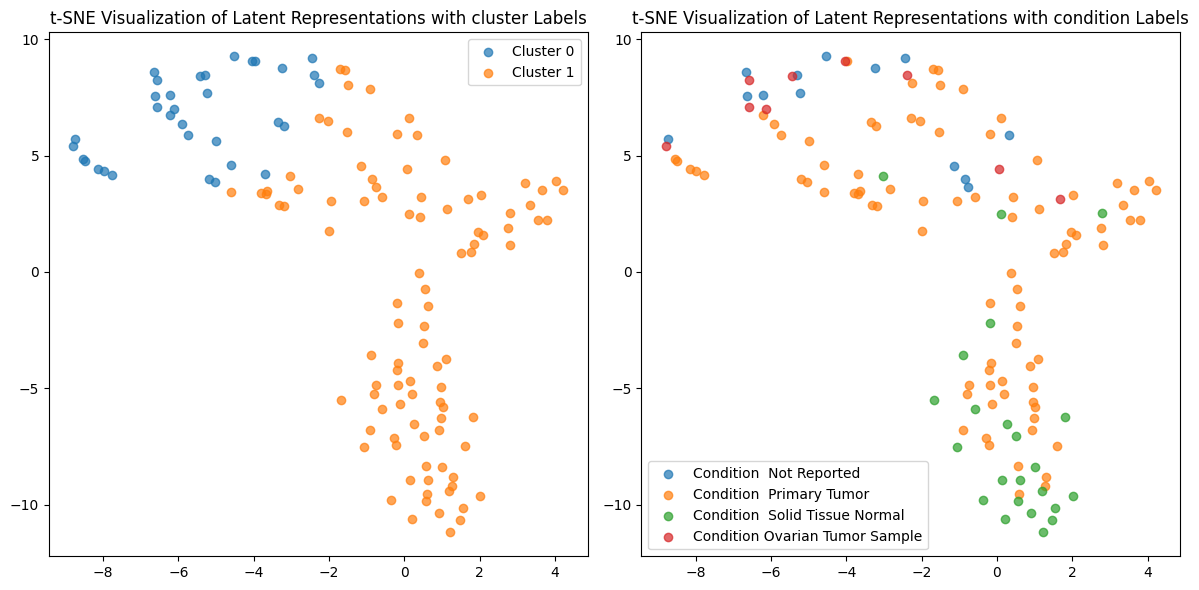

In [13]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2, random_state=0)
latent_2d = tsne.fit_transform(latent_representations)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for cluster in set(clusters):
    indices = (clusters == cluster)
    axes[0].scatter(latent_2d[indices, 0], latent_2d[indices, 1], label=f'Cluster {cluster}', alpha=0.7)
axes[0].set_title('t-SNE Visualization of Latent Representations with cluster Labels')
axes[0].legend()

conditions = conditions.values
unique_conditions = np.unique(conditions)
for condition in unique_conditions:
    indices = (conditions == condition)
    axes[1].scatter(
        latent_2d[indices, 0],
        latent_2d[indices, 1],
        label=f'Condition {condition}',
        alpha=0.7
    )
axes[1].set_title('t-SNE Visualization of Latent Representations with condition Labels')
axes[1].legend()

plt.tight_layout()
plt.show()

In [14]:
experiment_codes = np.array([patient_code.split("_")[0] for patient_code in patient_codes.to_list()])
experiment_codes

array(['01CPTAC', '01CPTAC', '01CPTAC', '01CPTAC', '01CPTAC', '01CPTAC',
       '01CPTAC', '01CPTAC', '01CPTAC', '01CPTAC', '02CPTAC', '02CPTAC',
       '02CPTAC', '02CPTAC', '02CPTAC', '02CPTAC', '02CPTAC', '02CPTAC',
       '02CPTAC', '02CPTAC', '03CPTAC', '03CPTAC', '03CPTAC', '03CPTAC',
       '03CPTAC', '03CPTAC', '03CPTAC', '03CPTAC', '03CPTAC', '03CPTAC',
       '04CPTAC', '04CPTAC', '04CPTAC', '04CPTAC', '04CPTAC', '04CPTAC',
       '04CPTAC', '04CPTAC', '04CPTAC', '04CPTAC', '05CPTAC', '05CPTAC',
       '05CPTAC', '05CPTAC', '05CPTAC', '05CPTAC', '05CPTAC', '05CPTAC',
       '05CPTAC', '05CPTAC', '06CPTAC', '06CPTAC', '06CPTAC', '06CPTAC',
       '06CPTAC', '06CPTAC', '06CPTAC', '06CPTAC', '06CPTAC', '06CPTAC',
       '07CPTAC', '07CPTAC', '07CPTAC', '07CPTAC', '07CPTAC', '07CPTAC',
       '07CPTAC', '07CPTAC', '07CPTAC', '07CPTAC', '08CPTAC', '08CPTAC',
       '08CPTAC', '08CPTAC', '08CPTAC', '08CPTAC', '08CPTAC', '08CPTAC',
       '08CPTAC', '08CPTAC', '09CPTAC', '09CPTAC', 

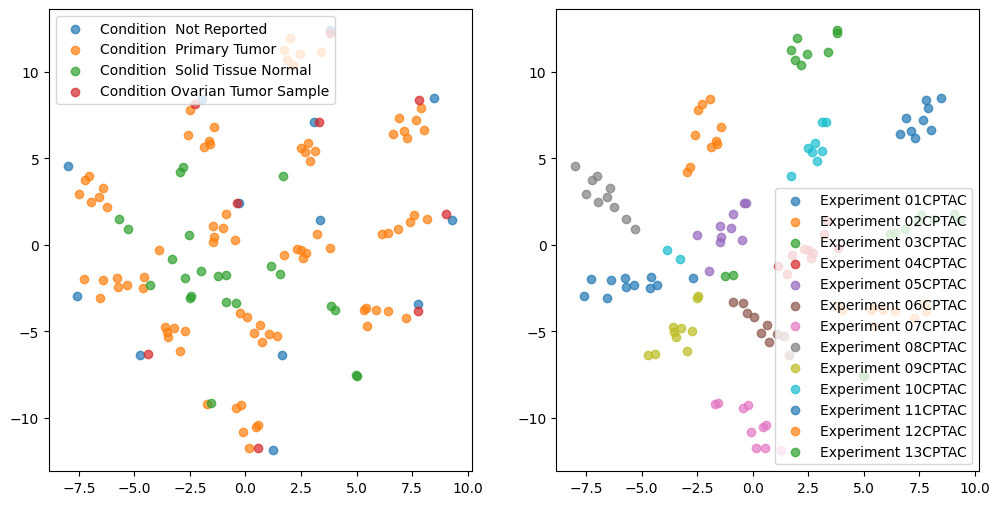

In [15]:
## baseline using TSNE

fig, axes = plt.subplots(1, 2, figsize=(12, 6))




tsne = TSNE(n_components=2, random_state=0)
df_2d = tsne.fit_transform(sample_data_normalized)
unique_conditions = np.unique(conditions)
for condition in unique_conditions:
    indices = (conditions == condition)
    axes[0].scatter(
        df_2d[indices, 0],
        df_2d[indices, 1],
        label=f'Condition {condition}',
        alpha=0.7
    )
axes[0].legend()

unique_experiments = np.unique(experiment_codes)

for experiment in unique_experiments:
    indices = (experiment_codes == experiment)
    axes[1].scatter(
        df_2d[indices, 0],
        df_2d[indices, 1],
        label=f'Experiment {experiment}',
        alpha=0.7
    )
axes[1].legend()



# Direct Autoencoder Clustering

In [17]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super(Autoencoder, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 500),
            nn.ReLU(),
            nn.Linear(500, 500),
            nn.ReLU(),
            nn.Linear(500, 2000),
            nn.ReLU(),
            nn.Linear(2000, latent_dim)
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 2000),
            nn.ReLU(),
            nn.Linear(2000, 500),
            nn.ReLU(),
            nn.Linear(500, 500),
            nn.ReLU(),
            nn.Linear(500, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        x_reconstructed = self.decoder(z)
        return z, x_reconstructed

class ClusteringLayer(nn.Module):
    def __init__(self, n_clusters, latent_dim):
        super(ClusteringLayer, self).__init__()
        self.cluster_centers = nn.Parameter(torch.randn(n_clusters, latent_dim))

    def forward(self, z):
        # Compute soft assignments (q_ij)
        q = 1.0 / (1.0 + torch.sum((z.unsqueeze(1) - self.cluster_centers)**2, dim=2))
        q = q / torch.sum(q, dim=1, keepdim=True)
        return q

# Step 3: Target Distribution Update
def target_distribution(q):
    weight = q ** 2 / torch.sum(q, dim=0)
    return (weight.t() / torch.sum(weight, dim=1)).t()

In [32]:
def encode_conditions(conditions : list):
    conditions_encoded = list()
    condition_codes = dict()
    next_code = 0
    for condition in conditions:
        if condition not in condition_codes:
            condition_codes[condition] = next_code
            next_code += 1
        conditions_encoded.append(condition_codes[condition])
    return conditions_encoded
encoded_conditions = encode_conditions(conditions)

In [33]:



X_tensor = proteomics_tensor
proteomics_dl = DataLoader(X_tensor, batch_size=64, shuffle=True)
input_dim = proteomics_tensor.shape[1]
latent_dim = 10
pre_training_epochs = 50
train_epochs = 100

y = encoded_conditions
n_clusters = len(np.unique(y))


autoencoder = Autoencoder(input_dim, latent_dim)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(autoencoder.parameters(), lr=1e-3)


In [34]:

for epoch in range(pre_training_epochs):  # Pre-train for 50 epochs
    z, X_reconstructed = autoencoder(X_tensor)
    loss = criterion(X_reconstructed, X_tensor)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}, Reconstruction Loss: {loss.item()}")

Epoch 10, Reconstruction Loss: 0.8754859566688538
Epoch 20, Reconstruction Loss: 0.7510300874710083
Epoch 30, Reconstruction Loss: 0.6622105836868286
Epoch 40, Reconstruction Loss: 0.560054361820221
Epoch 50, Reconstruction Loss: 0.44621601700782776


In [35]:
# init the clusterer through kmeans
with torch.no_grad():
    latent_representations = autoencoder.encoder(X_tensor).numpy()
kmeans = KMeans(n_clusters=n_clusters, n_init=20)
kmeans.fit(latent_representations)
initial_cluster_centers = torch.tensor(kmeans.cluster_centers_, dtype=torch.float32)

clustering_layer = ClusteringLayer(n_clusters, latent_dim)
clustering_layer.cluster_centers.data = initial_cluster_centers

In [36]:
optimizer_dec = torch.optim.Adam(list(autoencoder.parameters()) + list(clustering_layer.parameters()), lr=1e-3)

for epoch in range(train_epochs):  # Train DEC for 50 epochs
    z, X_reconstructed = autoencoder(X_tensor)
    q = clustering_layer(z)
    p = target_distribution(q)
    # KL Divergence Loss
    kl_loss = torch.nn.functional.kl_div(q.log(), p, reduction='batchmean')
    recon_loss = criterion(X_reconstructed, X_tensor)  # Optionally combine with reconstruction loss
    loss = kl_loss + 0.1 * recon_loss
    optimizer_dec.zero_grad()
    loss.backward()
    optimizer_dec.step()
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}, Total Loss: {loss.item()}, KL Loss: {kl_loss.item()}, Recon Loss: {recon_loss.item()}")


Epoch 10, Total Loss: 0.07397004216909409, KL Loss: 0.009707478806376457, Recon Loss: 0.6426255702972412
Epoch 20, Total Loss: 0.052585333585739136, KL Loss: 0.00499877380207181, Recon Loss: 0.47586560249328613
Epoch 30, Total Loss: 0.04155406355857849, KL Loss: 0.004164478275924921, Recon Loss: 0.3738958239555359
Epoch 40, Total Loss: 0.03442161902785301, KL Loss: 0.003922231495380402, Recon Loss: 0.3049938678741455
Epoch 50, Total Loss: 0.028827302157878876, KL Loss: 0.0037920952308923006, Recon Loss: 0.25035205483436584
Epoch 60, Total Loss: 0.02524205669760704, KL Loss: 0.0037035851273685694, Recon Loss: 0.21538472175598145
Epoch 70, Total Loss: 0.022169578820466995, KL Loss: 0.003650112310424447, Recon Loss: 0.18519465625286102
Epoch 80, Total Loss: 0.019818764179944992, KL Loss: 0.0036165898200124502, Recon Loss: 0.16202174127101898
Epoch 90, Total Loss: 0.018734125420451164, KL Loss: 0.0036172729451209307, Recon Loss: 0.15116852521896362
Epoch 100, Total Loss: 0.0168023593723773

In [37]:
with torch.no_grad():
    z, _ = autoencoder(X_tensor)
    q = clustering_layer(z)
    cluster_assignments = torch.argmax(q, dim=1).numpy()
ari = adjusted_rand_score(y, cluster_assignments)
print(f"Adjusted Rand Index (ARI): {ari}")

Adjusted Rand Index (ARI): 0.0


In [38]:
def extract_latent_space(model, data_loader):
    model.encoder.eval()
    latent_representations = []
    with torch.no_grad():
        for batch in data_loader:
            ######### NEW ##############
            # x = batch[0]
            # x = x.view(x.size(0), -1)
            ############################
            bach_latent_reepresentation = model.encoder(batch)
           
            latent_representations.append(bach_latent_reepresentation)
    return np.vstack(latent_representations)

# Here fixed model goae -> autoencoder
latent_representations = extract_latent_space(autoencoder, proteomics_tensor)

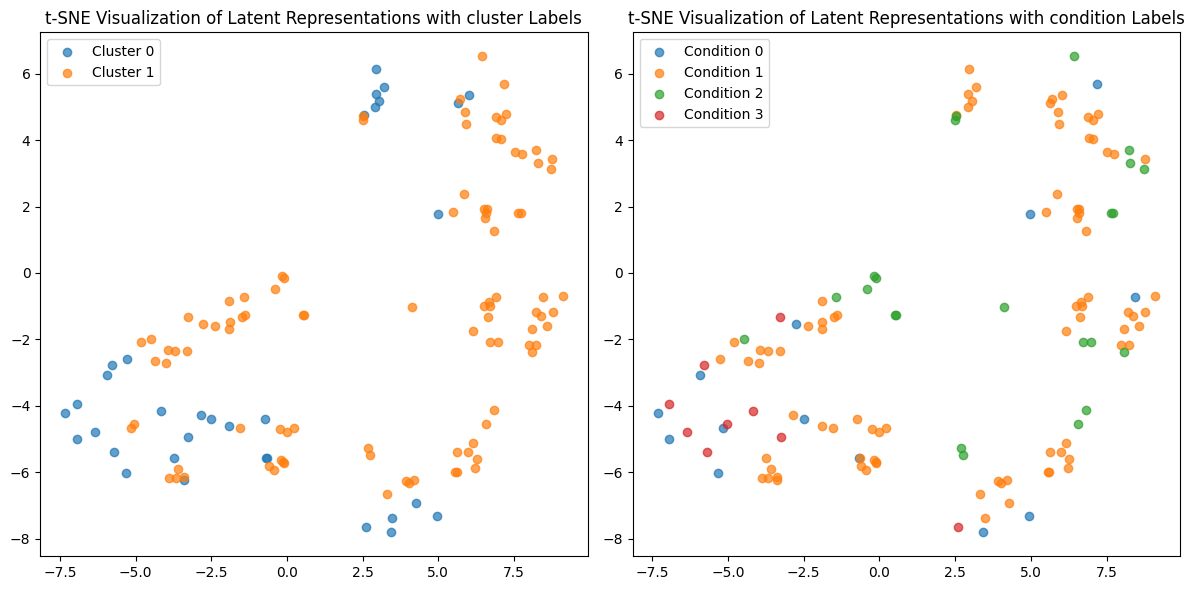

In [39]:

tsne = TSNE(n_components=2, random_state=0)
latent_2d = tsne.fit_transform(latent_representations)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for cluster in set(clusters):
    indices = (clusters == cluster)
    axes[0].scatter(latent_2d[indices, 0], latent_2d[indices, 1], label=f'Cluster {cluster}', alpha=0.7)
axes[0].set_title('t-SNE Visualization of Latent Representations with cluster Labels')
axes[0].legend()

conditions = encoded_conditions
unique_conditions = np.unique(conditions)
for condition in unique_conditions:
    indices = (conditions == condition)
    axes[1].scatter(
        latent_2d[indices, 0],
        latent_2d[indices, 1],
        label=f'Condition {condition}',
        alpha=0.7
    )
axes[1].set_title('t-SNE Visualization of Latent Representations with condition Labels')
axes[1].legend()

plt.tight_layout()
plt.show()